In [1]:
import pandas as pd

primary_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/dataFiles/names/names.csv')
names_df = primary_df.copy()

print("Информация о загруженном датафрейме с именами:")
primary_df.info()
display(primary_df.head())

Информация о загруженном датафрейме с именами:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553653 entries, 0 to 553652
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   name    553653 non-null  object
 1   year    553653 non-null  int64 
 2   num     553653 non-null  int64 
 3   total   553653 non-null  int64 
 4   sex     179881 non-null  object
dtypes: int64(3), object(2)
memory usage: 21.1+ MB


,name,year,num,total,sex
0,ЮРИЙ,1932,4245,187203,М
1,АЛЕКСАНДРА,1932,4136,187203,Ж
2,ТАМАРА,1932,4065,187203,Ж
3,ИВАН,1932,3685,187203,М
4,ЛЮДМИЛА,1932,3556,187203,Ж


### Анализ и подготовка данных о именах

In [2]:
men_df = primary_df[(primary_df['sex'] == 'М') & (primary_df['num'] > 10) &
                    (primary_df['year'] >= 1920) & (primary_df['year'] <= 1979)]

display(men_df.head())
men_df = men_df.drop(columns='sex')
display(men_df.head())


names_popularity = pd.DataFrame(men_df.groupby('name')['num'].sum())
display(names_popularity.head())

popular_names_df = names_popularity.sort_values(by='num', ascending=False).head(20)
display(popular_names_df.head())
popular_names_list = popular_names_df.index.tolist()


,name,year,num,total,sex
0,ЮРИЙ,1932,4245,187203,М
3,ИВАН,1932,3685,187203,М
7,ВАСИЛИЙ,1932,2968,187203,М
8,МИХАИЛ,1932,2949,187203,М
9,АЛЕКСЕЙ,1932,2946,187203,М


,name,year,num,total
0,ЮРИЙ,1932,4245,187203
3,ИВАН,1932,3685,187203
7,ВАСИЛИЙ,1932,2968,187203
8,МИХАИЛ,1932,2949,187203
9,АЛЕКСЕЙ,1932,2946,187203


,num
name,
АББАС,52
АБДУЛ,430
АБДУЛА,89
АБДУЛБЯР,13
АБДУЛЛА,477


,num
name,
АЛЕКСАНДР,780565
ВЛАДИМИР,663717
СЕРГЕЙ,628931
НИКОЛАЙ,434122
ВИКТОР,376084


In [3]:
outcomes_men_df = pd.pivot_table(
    data=men_df,
    values='num',
    index='year',
    columns='name'
)
display(outcomes_men_df.head(5))

outcomes_men_df = outcomes_men_df[popular_names_list]

display(outcomes_men_df.head(5))
outcomes_men_df.fillna(0, inplace=True)
display(outcomes_men_df.head(5))

name,АББАС,АБДУЛ,АБДУЛА,АБДУЛБЯР,АБДУЛЛА,АБДУЛХАЙ,АБДУРАХМАН,АБРАМ,АБУБАКАР,АВГУСТ,...,ЮСИФ,ЮСУП,ЮСУФ,ЯКОВ,ЯКУБ,ЯН,ЯНИС,ЯРОСЛАВ,ЯША,ЯШАР
year,,,,,,,,,,,,,,,,,,,,,
1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,NaN,NaN,...,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN
1921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,166.0,NaN,NaN,NaN,NaN,NaN,NaN
1922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,NaN,NaN,...,NaN,NaN,NaN,171.0,NaN,NaN,NaN,NaN,NaN,NaN
1923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0,NaN,NaN,...,NaN,NaN,NaN,157.0,NaN,NaN,NaN,NaN,NaN,NaN
1924,NaN,17.0,NaN,NaN,NaN,NaN,NaN,37.0,NaN,NaN,...,NaN,NaN,NaN,161.0,NaN,NaN,NaN,NaN,NaN,NaN


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
year,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,156.0,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,201.0,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,205.0,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,232.0,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,283.0,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
year,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,156.0,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,201.0,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,205.0,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,232.0,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,283.0,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0


In [4]:
predictors = outcomes_men_df.loc[outcomes_men_df.index <= 1960]
predictors['predictor_label'] = (predictors.index - 1920) // 5

display(predictors.head(5))
display(predictors.tail(5))

predictors = predictors.groupby('predictor_label').sum()
display(predictors.head(10))


/tmp/ipykernel_10644/1183946285.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictors['predictor_label'] = (predictors.index - 1920) // 5


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,...,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ,predictor_label
year,,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,...,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0,0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,...,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0,0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,...,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0,0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,...,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0,0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,...,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0,0


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,...,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ,predictor_label
year,,,,,,,,,,,,,,,,,,,,,
1956,27040.0,21491.0,21231.0,13536.0,11468.0,5590.0,8315.0,4674.0,7919.0,6429.0,...,1357.0,4778.0,5540.0,2229.0,3785.0,2331.0,3367.0,2169.0,3215.0,7
1957,27029.0,20611.0,21684.0,12608.0,11008.0,6327.0,8214.0,5499.0,8106.0,5910.0,...,1594.0,4871.0,5430.0,2315.0,3540.0,2459.0,3507.0,2055.0,3183.0,7
1958,27324.0,19941.0,24600.0,12112.0,10470.0,6582.0,8300.0,7302.0,8564.0,5450.0,...,1751.0,4885.0,5399.0,2891.0,3422.0,2431.0,3325.0,2121.0,3273.0,7
1959,25350.0,18534.0,24342.0,11071.0,9600.0,6655.0,7879.0,9701.0,8294.0,5007.0,...,1864.0,4668.0,5731.0,3308.0,3327.0,2395.0,3197.0,1966.0,3429.0,7
1960,25388.0,18451.0,26089.0,10341.0,9062.0,7597.0,7858.0,11781.0,8572.0,4573.0,...,2635.0,4637.0,5507.0,4312.0,3657.0,2353.0,3096.0,2020.0,3716.0,8


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
predictor_label,,,,,,,,,,,,,,,,,,,,
0,10798.0,10004.0,5999.0,17006.0,6343.0,7481.0,2941.0,1673.0,9384.0,4220.0,1077.0,2657.0,2760.0,411.0,579.0,551.0,12694.0,9519.0,4435.0,780.0
1,23105.0,26741.0,10768.0,37622.0,20784.0,15843.0,10982.0,2736.0,17759.0,15483.0,2665.0,5249.0,7892.0,1204.0,1585.0,1983.0,23332.0,18813.0,10047.0,3026.0
2,22856.0,33144.0,8465.0,34512.0,26203.0,13629.0,19162.0,2084.0,14039.0,22771.0,4063.0,3872.0,10963.0,1683.0,2717.0,3593.0,17715.0,14003.0,13165.0,5187.0
3,32657.0,62266.0,10237.0,38995.0,46933.0,13546.0,40866.0,2609.0,14143.0,45350.0,9021.0,3911.0,20570.0,12430.0,7301.0,16800.0,14321.0,11308.0,20775.0,13360.0
4,29901.0,48234.0,9217.0,29448.0,33827.0,9748.0,25087.0,2442.0,11595.0,29575.0,6161.0,2848.0,13744.0,20263.0,4676.0,15381.0,8973.0,7996.0,13822.0,9930.0
5,75302.0,90224.0,26485.0,55682.0,56261.0,16358.0,35283.0,5186.0,25175.0,39896.0,9339.0,4509.0,21987.0,27496.0,6769.0,19005.0,9284.0,11373.0,17989.0,13269.0
6,114749.0,106575.0,62607.0,63953.0,58635.0,22465.0,37956.0,10701.0,31589.0,36979.0,14842.0,5319.0,23449.0,28971.0,8744.0,19412.0,10565.0,14596.0,12975.0,14035.0
7,133615.0,103119.0,110989.0,62628.0,54259.0,30515.0,41257.0,31236.0,40259.0,29598.0,29112.0,7908.0,24299.0,28318.0,12683.0,18234.0,11872.0,16605.0,10716.0,16360.0
8,25388.0,18451.0,26089.0,10341.0,9062.0,7597.0,7858.0,11781.0,8572.0,4573.0,9731.0,2635.0,4637.0,5507.0,4312.0,3657.0,2353.0,3096.0,2020.0,3716.0


In [5]:
import matplotlib
def plot(synth_tables):
    synth_Y1, Y1 = synth_tables[0], synth_tables[1]
    plt.plot(range(len(synth_Y1)),synth_Y1, 'r--', label="Synthetic Control")
    plt.plot(range(len(synth_Y1)),Y1, 'b-', label="Actual Data")
    plt.title("Example Synthetic Control Model")
    plt.ylabel("Y axis")
    plt.xlabel("X axis")
    plt.legend(loc='upper left')
    plt.show()


In [9]:
import sys
import importlib
sys.path.append('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/src/scmlib')
# Принудительно перезагружаем модуль main, чтобы убедиться, что используется новая версия
if 'scmsolver' in sys.modules:
    scmsolver = importlib.reload(sys.modules['scmsolver'])
else:
    import scmsolver

from scmsolver import scm_solve
from scmsolver import basic_dataprep
X0, X1, Y0_pre, Y1_pre, Y0, Y1 = scmsolver.basic_dataprep(predictors,
                             outcomes_men_df,
                             'ЮРИЙ',
                             predictors.columns.drop('ЮРИЙ').tolist(),
                             list(range(1920, 1961)), list(range(1920, 1980)))
res = scmsolver.scm_solve(Y0.values, Y0_pre.values, Y1_pre.values, X0.values, X1.values) # returned: {V, W, Y_1_synth}

# synth_tables = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table
names_table1 = [res['Y_1_synth'], Y1, res['V'], res['W'], predictors, outcomes_men_df]

plot(names_table1)

n_features = x0.shape[0]: 9, n_donors = x0.shape[1]: 19


/usr/local/lib/python3.13/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Оптимизация V и W успешно завершена(50 iterations). returned: {V, W, Y_1_synth}



NameError: name 'plt' is not defined

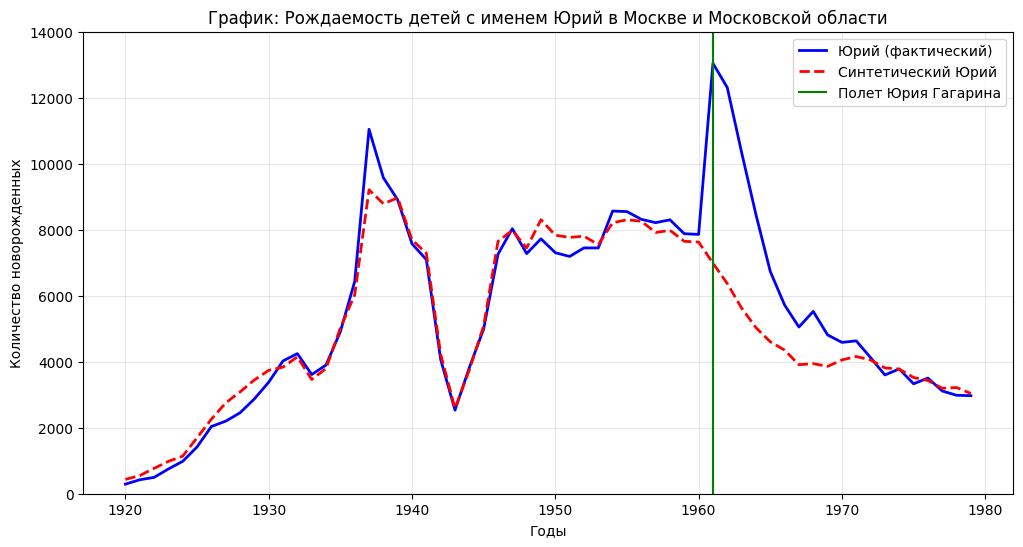

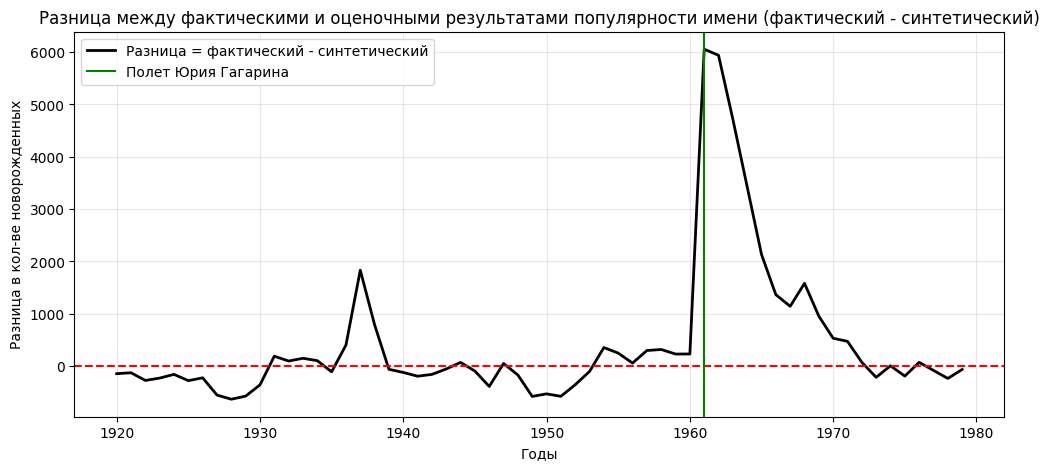

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# names_table1 = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table
# 1. Расчет временного ряда
years = np.arange(1920, 1980)
# Y_1_synth = Y_1 @ W_opt_abadie
Y1_synth = names_table1[0]
Y1 = names_table1[1]
# 2. Построение графика:
plt.figure(figsize=(12, 6))
plt.plot(years, Y1, 'b-', label='Юрий (фактический)', linewidth=2)
plt.plot(years, Y1_synth, 'r--', label='Синтетический Юрий', linewidth=2)
plt.axvline(x=1961, color='green', linestyle='-', label='Полет Юрия Гагарина')
plt.title('График: Рождаемость детей с именем Юрий в Москве и Московской области')
plt.xlabel('Годы')
plt.ylabel('Количество новорожденных')
plt.ylim(0, 14000)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("my_namesmain.png", dpi=600, bbox_inches="tight")
plt.show()

# 3. График разности (Gap Plot)
gap = Y1 - Y1_synth

plt.figure(figsize=(12, 5))
plt.plot(years, gap, 'k-', linewidth=2, label='Разница = фактический - синтетический')
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=1961, color='green', linestyle='-', label='Полет Юрия Гагарина')
plt.title('Разница между фактическими и оценочными результатами популярности имени (фактический - синтетический)')
plt.xlabel('Годы')
plt.ylabel('Разница в кол-ве новорожденных')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("my_namesgap.png", dpi=600, bbox_inches="tight")
plt.show()

# ДАЛЕЕ ЛЕГАСИ НЕАКТУАЛЬНОЕ


In [ ]:
# 1. Отфильтруем данные для явного пола ('М' или 'Ж')
names_filtered_sex = names_df[names_df['sex'].isin(['М', 'Ж'])].copy()

# 2. Вычислим количество уникальных мужских и женских имен
unique_male_names = names_filtered_sex[names_filtered_sex['sex'] == 'М']['name'].nunique()
unique_female_names = names_filtered_sex[names_filtered_sex['sex'] == 'Ж']['name'].nunique()

print(f"Количество уникальных мужских имен: {unique_male_names}")
print(f"Количество уникальных женских имен: {unique_female_names}")

# 3. Определим 300 самых популярных мужских и женских имен
# Агрегируем 'num' по имени и полу, чтобы получить общую популярность
name_popularity = names_filtered_sex.groupby(['name', 'sex'])['num'].sum().reset_index()

display(name_popularity.head())
print(type(name_popularity))

top_male_names_df = name_popularity[name_popularity['sex'] == 'М'].sort_values(by='num', ascending=False).head(300)
top_female_names_df = name_popularity[name_popularity['sex'] == 'Ж'].sort_values(by='num', ascending=False).head(300)

top_male_names_list = top_male_names_df['name'].tolist()
top_female_names_list = top_female_names_df['name'].tolist()

print(f"\n300 самых популярных мужских имен (первые 5):\n{top_male_names_list[:5]}")
print(f"300 самых популярных женских имен (первые 5):\n{top_female_names_list[:5]}")

# Объединим списки имен и добавим "population" для нового DataFrame
all_top_names = top_male_names_list + top_female_names_list

# Проверим, есть ли дубликаты среди top имен, если имя может быть и мужским, и женским
# В этом случае, я выбираю сохранить имя с тем полом, который был определен как самый популярный
# или просто сохранить его как одно уникальное имя, а затем присвоить ему пол из соответствующего списка
# Для простоты, пока просто объединяем, предполагая, что 300 мужских и 300 женских не пересекаются или мы хотим их отдельно хранить
# Если будут пересечения, то в финальном DF будет меньше 600 уникальных строк + population

# Если нужно, чтобы имена не повторялись, даже если они в обоих топ-списках (что маловероятно для топ-300):
# unique_all_top_names = list(set(top_male_names_list + top_female_names_list))
# Но запрос про 300 мужских И 300 женских, так что будем считать, что это 600 строк.
# Если имя может быть и мужским, и женским, мы включим его дважды с разными метками пола.


Количество уникальных мужских имен: 3447
Количество уникальных женских имен: 2734


,name,sex,num
0,АБАКАР,М,132
1,АБАТ,М,15
2,АББАС,М,243
3,АББЯЗ,М,7
4,АББЯС,М,163


<class 'pandas.core.frame.DataFrame'>

300 самых популярных мужских имен (первые 5):
['АЛЕКСАНДР', 'СЕРГЕЙ', 'ВЛАДИМИР', 'АЛЕКСЕЙ', 'НИКОЛАЙ']
300 самых популярных женских имен (первые 5):
['ТАТЬЯНА', 'ЕЛЕНА', 'ОЛЬГА', 'НАТАЛЬЯ', 'ИРИНА']


### Создание нового DataFrame с требуемой структурой

In [ ]:
# Получим все уникальные года
# years = sorted(names_filtered_sex['year'].unique().tolist())
years = list(range(1920, 1980))

# Подготовим данные для нового DataFrame
# Для имен: создадим комбинированный список кортежей (имя, пол),
# чтобы сохранить уникальность по полу
name_sex_pairs = []
for name in top_male_names_list:
    name_sex_pairs.append((name, 'М'))
for name in top_female_names_list:
    name_sex_pairs.append((name, 'Ж'))

# Создадим список индексов для нового DataFrame
new_index = [f"{name}_{sex}" for name, sex in name_sex_pairs] + ['population']

# Создадим новый DataFrame
new_df_columns = ['sex'] + years
new_df = pd.DataFrame(index=new_index, columns=new_df_columns, dtype=float)

# Заполним столбец 'sex'
for name, sex in name_sex_pairs:
    new_df.loc[f"{name}_{sex}", 'sex'] = sex

# Заполним данные о количестве по годам для имен
# Сначала создадим pivot table для удобства извлечения данных
pivoted_names = names_filtered_sex.pivot_table(index=['name', 'sex'], columns='year',
                                               values='num', fill_value=0)

for name, sex in name_sex_pairs:
    if (name, sex) in pivoted_names.index:
        new_df.loc[f"{name}_{sex}", years] = pivoted_names.loc[(name, sex), years]
    else:
        # Если по какой-то причине имени с этим полом нет в pivoted_names (например, фильтрация)
        new_df.loc[f"{name}_{sex}", years] = 0

# Заполним строку 'population'
# Столбец 'total' в исходном names_df уже представляет общее количество имен за год
population_data = names_df.groupby('year')['total'].first() # 'first' или 'mean' так как 'total' одинаков для всех строк года

for year in years:
    if year in population_data.index:
        new_df.loc['population', year] = population_data.loc[year]
    else:
        new_df.loc['population', year] = 0 # В случае, если какой-то год отсутствует

# Преобразуем 'sex' колонку обратно в object/string, если она стала float из-за NaN и fill_value=0
# new_df['sex'] = new_df['sex'].astype(str)

print("\nНовый DataFrame успешно создан. Информация о нем:")
new_df.info()
display(new_df.head(10)) # Покажем первые 10 строк, включая часть имен и строку population
display(new_df.tail()) # Покажем последние строки


/tmp/ipykernel_708/863895223.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'М' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  new_df.loc[f"{name}_{sex}", 'sex'] = sex



Новый DataFrame успешно создан. Информация о нем:
<class 'pandas.core.frame.DataFrame'>
Index: 601 entries, АЛЕКСАНДР_М to population
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     600 non-null    object 
 1   1920    601 non-null    float64
 2   1921    601 non-null    float64
 3   1922    601 non-null    float64
 4   1923    601 non-null    float64
 5   1924    601 non-null    float64
 6   1925    601 non-null    float64
 7   1926    601 non-null    float64
 8   1927    601 non-null    float64
 9   1928    601 non-null    float64
 10  1929    601 non-null    float64
 11  1930    601 non-null    float64
 12  1931    601 non-null    float64
 13  1932    601 non-null    float64
 14  1933    601 non-null    float64
 15  1934    601 non-null    float64
 16  1935    601 non-null    float64
 17  1936    601 non-null    float64
 18  1937    601 non-null    float64
 19  1938    601 non-null    float64
 20  1939    601 n

,sex,1920,1921,1922,1923,1924,1925,1926,1927,1928,...,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979
АЛЕКСАНДР_М,М,1461.0,1858.0,2170.0,2490.0,2819.0,3442.0,4674.0,4958.0,5129.0,...,15483.0,16057.0,16604.0,15712.0,16265.0,15305.0,15615.0,15574.0,15483.0,16255.0
СЕРГЕЙ_М,М,839.0,1057.0,1207.0,1346.0,1550.0,1885.0,2211.0,2314.0,2226.0,...,19079.0,20376.0,19924.0,19084.0,19215.0,18700.0,18015.0,16851.0,17015.0,16134.0
ВЛАДИМИР_М,М,1082.0,1365.0,1604.0,2140.0,3813.0,4542.0,5200.0,5469.0,5702.0,...,9587.0,7472.0,7457.0,6918.0,6890.0,6440.0,6237.0,5846.0,5953.0,5584.0
АЛЕКСЕЙ_М,М,1050.0,1316.0,1477.0,1541.0,2097.0,2514.0,3237.0,3335.0,3567.0,...,9730.0,12572.0,14648.0,15141.0,16010.0,18066.0,17633.0,17204.0,17717.0,16966.0
НИКОЛАЙ_М,М,2314.0,2817.0,3375.0,3869.0,4631.0,5895.0,7208.0,8336.0,8281.0,...,3631.0,3634.0,3661.0,3498.0,3650.0,3470.0,3459.0,3475.0,3911.0,3805.0
АНДРЕЙ_М,М,253.0,310.0,361.0,361.0,388.0,483.0,625.0,570.0,552.0,...,12984.0,12884.0,13292.0,12473.0,12874.0,11962.0,11953.0,11581.0,11758.0,11475.0
ВИКТОР_М,М,616.0,942.0,1100.0,1539.0,2146.0,2969.0,3970.0,4338.0,4679.0,...,2681.0,2619.0,2493.0,2434.0,2403.0,2227.0,2272.0,2109.0,2021.0,2163.0
МИХАИЛ_М,М,1321.0,1646.0,1888.0,2163.0,2366.0,2987.0,3673.0,3858.0,3793.0,...,5670.0,5779.0,5822.0,5630.0,5770.0,5616.0,5175.0,5115.0,5252.0,5202.0
ЮРИЙ_М,М,290.0,423.0,495.0,751.0,982.0,1419.0,2037.0,2199.0,2453.0,...,4586.0,4632.0,4125.0,3599.0,3781.0,3331.0,3504.0,3113.0,2983.0,2971.0
ДМИТРИЙ_М,М,407.0,471.0,518.0,598.0,663.0,927.0,1079.0,1075.0,1169.0,...,10758.0,12048.0,11925.0,11797.0,11798.0,12251.0,12573.0,11655.0,12098.0,11769.0


,sex,1920,1921,1922,1923,1924,1925,1926,1927,1928,...,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979
ВАНДА_Ж,Ж,12.0,4.0,10.0,5.0,13.0,12.0,9.0,10.0,10.0,...,13.0,8.0,6.0,2.0,3.0,5.0,3.0,2.0,7.0,6.0
ЛЕОНОРА_Ж,Ж,0.0,1.0,3.0,2.0,6.0,6.0,10.0,5.0,12.0,...,2.0,1.0,5.0,2.0,3.0,3.0,0.0,0.0,1.0,1.0
АКСАНА_Ж,Ж,0.0,1.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,...,24.0,26.0,39.0,18.0,38.0,46.0,20.0,21.0,37.0,17.0
ЖАНЕТТА_Ж,Ж,0.0,0.0,1.0,0.0,0.0,2.0,1.0,4.0,3.0,...,10.0,11.0,4.0,8.0,2.0,7.0,7.0,9.0,5.0,4.0
population,NaN,73135.0,85856.0,105416.0,124732.0,139774.0,158563.0,177690.0,185493.0,193644.0,...,329156.0,336794.0,342768.0,332757.0,342494.0,339637.0,342664.0,337248.0,345119.0,342396.0


In [ ]:
import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.optimize import minimize

# 1. Определяем целевое имя и период
target_name = 'ЮРИЙ_М'
intervention_year = 1961
pre_period = [y for y in years if y < intervention_year]

# 2. Формируем донорский пул
# Исключаем целевое имя и запрещенные имена
excluded = [target_name, 'ВАЛЕРИЙ_М', 'ГЕРМАН_М', 'ВАЛЕНТИНА_Ж']

# Выбираем топ-50 имен по суммарной популярности
donor_candidates = name_popularity.copy()
donor_candidates['name_id'] = donor_candidates['name'] + '_' + donor_candidates['sex']
donor_candidates = donor_candidates[~donor_candidates['name_id'].isin(excluded)]
top_donors = donor_candidates.sort_values(by='num', ascending=False).head(50)['name_id'].tolist()

# Добавляем population в пул доноров
donor_pool_ids = top_donors + ['population']

# 3. Подготовка матриц Y (результаты)
Y_0 = new_df.loc[target_name, years].astype(float).to_numpy()
Y_0_pre = new_df.loc[target_name, pre_period].astype(float).to_numpy()

Y_1 = new_df.loc[donor_pool_ids, years].astype(float).to_numpy().T
Y_1_pre = new_df.loc[donor_pool_ids, pre_period].astype(float).to_numpy().T

# 4. Подготовка признаков X (для подбора весов)
# Разделяем пре-период на 8 частей по 5 лет (1920-1924, 1925-1929, ...)
# Так как pre_period содержит 41 год (1920-1960 включительно),
# мы создадим 8 групп, где последние годы будут в финальной группе.
periods = [pre_period[i:i + 5] for i in range(0, len(pre_period), 5)]

X_list_0 = [new_df.loc[target_name, p].mean() for p in periods]
X_0_names = np.array(X_list_0)

X_list_1 = [new_df.loc[donor_pool_ids, p].mean(axis=1).to_numpy() for p in periods]
X_1_names = np.stack(X_list_1, axis=0) # Транспонируем, чтобы получить shape(features, donors)

print(f"Целевое имя: {target_name}")
print(f"Размер донорского пула: {len(donor_pool_ids)}")
print(f"Количество ковариатов в X: {len(periods)}")
print(f"Форма X_0: {X_0_names.shape}, X_1: {X_1_names.shape}")
print()

Целевое имя: ЮРИЙ_М
Размер донорского пула: 51
Количество ковариатов в X: 9
Форма X_0: (9,), X_1: (9, 51)



### Оптимизация весов (Синтетический контроль для Юрия)

In [ ]:
n_features = X_1_names.shape[1]
n_donors = X_1_names.shape[0]

def solve_w_names(v_diag, x0, x1):
    """Решение внутренней задачи оптимизации для поиска весов W при фиксированном V."""
    w = cp.Variable(n_donors)
    v_mat = np.diag(v_diag)
    # x1.T has shape (n_features, n_donors), x0 has shape (n_features,)
    obj = cp.Minimize(cp.quad_form(x0 - x1.T @ w, v_mat))
    constraints = [w >= 0, cp.sum(w) == 1]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.SCS, eps=1e-6)
    return w.value

def objective_v_names(v_diag):
    """Внешняя целевая функция: минимизация RMSPE в пре-периоде."""
    v_diag_norm = v_diag / np.linalg.norm(v_diag)
    w_star = solve_w_names(v_diag_norm, X_0_names, X_1_names)
    if w_star is None: return 1e10
    # Считаем ошибку аппроксимации временного ряда до 1961 года
    error = np.sqrt(np.mean(np.square(Y_0_pre - Y_1_pre @ w_star)))
    return error

# Начальное приближение
v_start = np.ones(n_features) / n_features

print("Запуск процесса оптимизации V и W... ")
res = minimize(
    objective_v_names,
    v_start,
    method='L-BFGS-B',
    bounds=[(1e-6, None)] * n_features,
    options={'maxiter': 10}
)

# Финальные веса
V_diag_final = res.x / np.linalg.norm(res.x)
W_opt_names = solve_w_names(V_diag_final, X_0_names, X_1_names)

print("Оптимизация завершена.\n")
# Вывод значимых весов
weights_series = pd.Series(W_opt_names, index=donor_pool_ids).sort_values(ascending=False)
print("Топ весов доноров для синтетического Юрия:")
display(weights_series[weights_series > 0.01])

Запуск процесса оптимизации V и W... 


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (9,) and arg 1 with shape (51,).

### Оптимизация весов (Синтетический контроль для Юрия)

In [ ]:
import sys
import importlib

# Добавляем путь к вашей библиотеке в системный путь
sys.path.append('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/src/scmlib')

# Принудительно перезагружаем модуль main, чтобы убедиться, что используется новая версия
if 'scmsolver' in sys.modules:
    scmsolver = importlib.reload(sys.modules['scmsolver'])
else:
    import scmsolver

# Теперь мы можем импортировать функцию из нашего модуля
from scmsolver import scm_solve

# Обновляем вызов функции scm_solve с необходимыми аргументами
res = scm_solve(Y_1, Y_0_pre, Y_1_pre, X_0_names, X_1_names)
print("Оптимизация завершена.")
# Выведем значимые веса
weights_series = pd.Series(res['W'], index=donor_pool_ids).sort_values(ascending=False)
print("\nТоп весов доноров для синтетического Юрия:")
display(weights_series[weights_series > 0.01])

NameError: name 'Y_1' is not defined

### Визуализация результатов: Реальный vs Синтетический Юрий

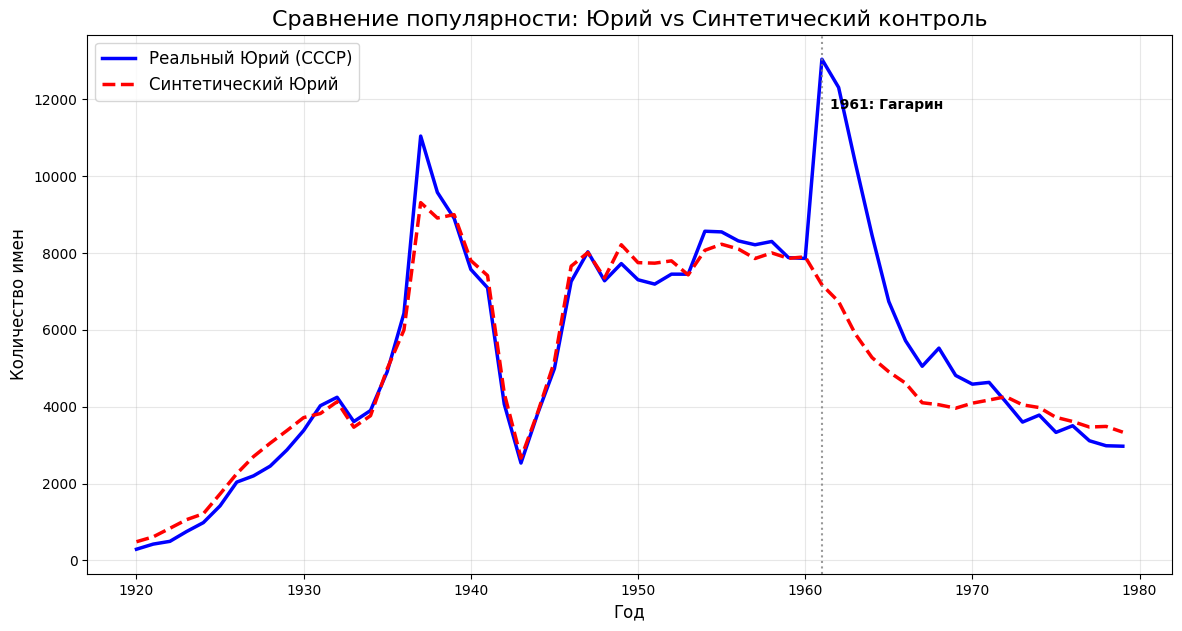

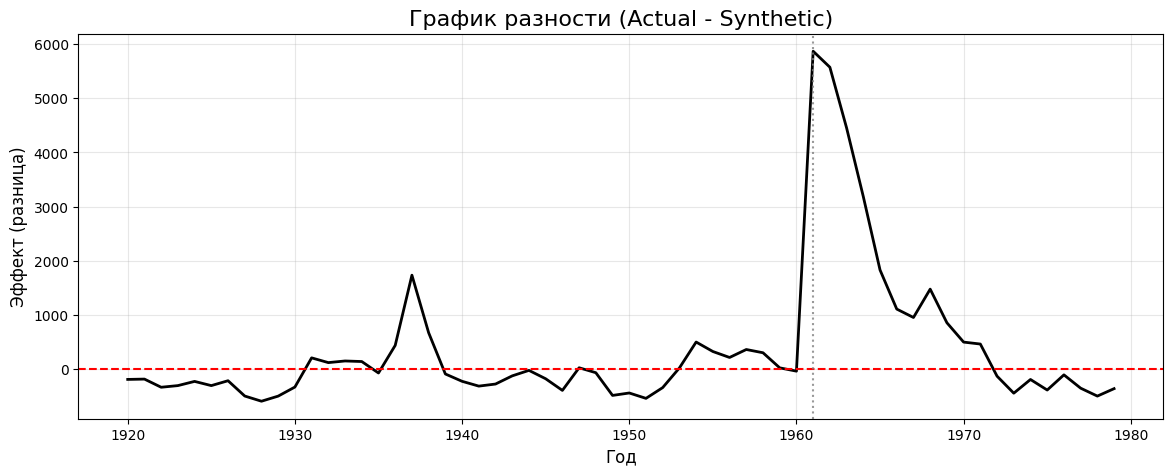

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Расчет синтетического временного ряда
# Y_1 имеет форму (года, доноры), W_opt_names - (доноры,)
Y_0_synthetic = Y_1 @ W_opt_names

# 2. Основной график
plt.figure(figsize=(14, 7))
plt.plot(years, Y_0, 'b-', label='Реальный Юрий (СССР)', linewidth=2.5)
plt.plot(years, Y_0_synthetic, 'r--', label='Синтетический Юрий', linewidth=2.5)

# Отметка 1961 года
plt.axvline(x=1961, color='gray', linestyle=':', alpha=0.8)
plt.text(1961.5, max(Y_0)*0.9, '1961: Гагарин', color='black', fontweight='bold')

plt.title('Сравнение популярности: Юрий vs Синтетический контроль', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество имен', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 3. График разности (Gap)
gap = Y_0 - Y_0_synthetic

plt.figure(figsize=(14, 5))
plt.plot(years, gap, 'k-', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=1961, color='gray', linestyle=':', alpha=0.8)
plt.title('График разности (Actual - Synthetic)', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Эффект (разница)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Визуализация результатов: Реальный vs Синтетический Юрий

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Вычисляем синтетический временной ряд
# Y_1 имеет форму (years, donors), W_opt_names имеет форму (donors,)
Y_0_synthetic = Y_1 @ W_opt_names

# 2. Построение основного графика
plt.figure(figsize=(14, 7))
plt.plot(years, Y_0, 'b-', label='Реальный Юрий (СССР)', linewidth=2.5)
plt.plot(years, Y_0_synthetic, 'r--', label='Синтетический Юрий', linewidth=2.5)

# Отметка года полета Гагарина
plt.axvline(x=1961, color='gray', linestyle=':', alpha=0.8)
plt.text(1961.5, max(Y_0)*0.9, '1961: Полет Гагарина', color='black', fontweight='bold')

plt.title('Эффект вмешательства: Популярность имени Юрий vs Синтетический контроль', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество рожденных с этим именем', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 3. График разности (Gap Plot)
gap = Y_0 - Y_0_synthetic

plt.figure(figsize=(14, 5))
plt.plot(years, gap, 'k-', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=1961, color='gray', linestyle=':', alpha=0.8)
plt.title('Разность между реальным и синтетическим Юрием (Gap)', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Разница (Эффект)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Создание файла `.py` из кода в ноутбуке

In [ ]:
library_folder = '/content/drive/MyDrive/КурсоваяСинтетическийКонтроль/src/scmlib'
file_name = 'sc_solver.py'
file_path = f'{library_folder}/{file_name}'

# Убедимся, что папка существует
import os
os.makedirs(library_folder, exist_ok=True)

# Код, который мы хотим сохранить в sc_solver.py
# Возьмем вашу функцию solve_w_names и зависимости
sc_solver_code = """
import cvxpy as cp
import numpy as np

def solve_w_names(v_diag, x0, x1):
    '''Решение внутренней задачи оптимизации для поиска весов W при фиксированном V.'''
    n_donors = x1.shape[0]
    w = cp.Variable(n_donors)
    v_mat = np.diag(v_diag)
    # x1.T has shape (n_features, n_donors), x0 has shape (n_features,)
    # В оригинальном коде X_1_names имеет форму (51, 9), то есть (n_donors, n_features).
    # Для cp.quad_form(x0 - x1 @ w, v_mat), x1 должно быть (n_features, n_donors).
    # В вашем случае, x1.T (n_features, n_donors) и w (n_donors,). x1.T @ w будет (n_features,)
    obj = cp.Minimize(cp.quad_form(x0 - x1.T @ w, v_mat))
    constraints = [w >= 0, cp.sum(w) == 1]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.SCS, eps=1e-6)
    return w.value
"""

with open(file_path, 'w', encoding='utf-8') as f:
    f.write(sc_solver_code)

print(f"Файл '{file_name}' успешно создан в '{library_folder}'")

Да, конечно, это вполне возможно! Вы можете превратить написанный вами код в Python-библиотеку и сохранить её в папку 'КурсоваяСинтетическийКонтроль' на вашем Google Диске. Вот как это можно сделать:

1.  **Организация кода:** Сначала вам нужно организовать ваш код. Вместо того, чтобы держать весь код в одной ячейке или в виде последовательных скриптов, выделите ключевые функции и классы, которые реализуют логику синтетического контроля (например, функции для подготовки данных, оптимизации весов W и V, построения графиков). Поместите эти функции и классы в отдельные `.py` файлы.
2.  **Создание пакета Python:** Создайте папку, например, `synthetic_control_lib`, которая будет служить вашей библиотекой. Внутри этой папки создайте файл `__init__.py` (он может быть пустым) — это укажет Python, что данная папка является пакетом. Ваши `.py` файлы с функциями поместите также в эту папку.
3.  **Установка и использование:** Чтобы использовать вашу библиотеку в других ноутбуках или скриптах, вам нужно будет либо скопировать её в соответствующее место, либо установить её. В Colab самый простой способ — это импортировать её напрямую, если она находится в вашей текущей рабочей директории или в смонтированном Google Диске.
4.  **Сохранение на Google Диске:** После того как вы организуете структуру вашей библиотеки (папку с `.py` файлами и `__init__.py`), вы можете просто сохранить её в папке `/content/drive/MyDrive/КурсоваяСинтетическийКонтроль`. Затем в других ноутбуках вы сможете добавить эту папку в системный путь и импортировать вашу библиотеку:

    ```python
    import sys
    sys.path.append('/content/drive/MyDrive/КурсоваяСинтетическийКонтроль/synthetic_control_lib')
    import your_module_name # Замените на имя вашего файла без .py
    
    # Теперь вы можете использовать функции из вашей библиотеки
    # your_module_name.some_function()
    ```

Это позволит вам переиспользовать ваш код, делать его более модульным и легко обновляемым. Если вам потребуется помощь с рефакторингом кода в такую структуру, дайте знать!

### Импорт и использование созданной библиотеки

In [ ]:
import sys

# Добавляем путь к вашей библиотеке в системный путь
# Обратите внимание, что мы добавляем путь до папки scmlib, а не до самого файла
sys.path.append('/content/drive/MyDrive/КурсоваяСинтетическийКонтроль/src/scmlib')

# Теперь мы можем импортировать функцию из нашего модуля
from sc_solver import solve_w_names

print("Функция solve_w_names успешно импортирована.")

# Для демонстрации, можем попробовать вызвать её с фиктивными данными (или вашими X_0_names, X_1_names)
# n_features = X_1_names.shape[1] # Количество признаков
# n_donors = X_1_names.shape[0]   # Количество доноров
# v_dummy = np.ones(n_features) / n_features
# w_test = solve_w_names(v_dummy, X_0_names, X_1_names)
# print("Тестовый запуск solve_w_names прошел успешно (если данные определены).")

ModuleNotFoundError: No module named 'sc_solver'

In [ ]:
import sys
import importlib
import os

library_path = '/content/drive/MyDrive/КурсоваяСинтетическийКонтроль/src/scmlib'

# Добавляем путь к вашей библиотеке в системный путь, если его там еще нет
if library_path not in sys.path:
    sys.path.append(library_path)

# Инвалидируем кэши импорта, чтобы Python заново искал модули
importlib.invalidate_caches()

# Проверяем содержимое папки, чтобы убедиться, что main.py существует
print(f"Содержимое директории '{library_path}':")
print(os.listdir(library_path))

# Теперь пробуем импортировать main.py
try:
    import main
    print("Модуль 'main' успешно импортирован.")
    # Если вы знаете конкретные функции, вы можете импортировать их напрямую:
    # from main import some_function, another_function
    # print("Функции из 'main' успешно импортированы.")
except ModuleNotFoundError:
    print(f"Ошибка: Модуль 'main' не найден в '{library_path}'. Убедитесь, что файл называется main.py")
except Exception as e:
    print(f"Произошла ошибка при импорте модуля 'main': {e}")

Содержимое директории '/content/drive/MyDrive/КурсоваяСинтетическийКонтроль/src/scmlib':
['__init__.py', '.ipynb_checkpoints', 'main.py', 'sc_solver.py', '__pycache__']
Модуль 'main' успешно импортирован.


### Визуализация показателя 'population'

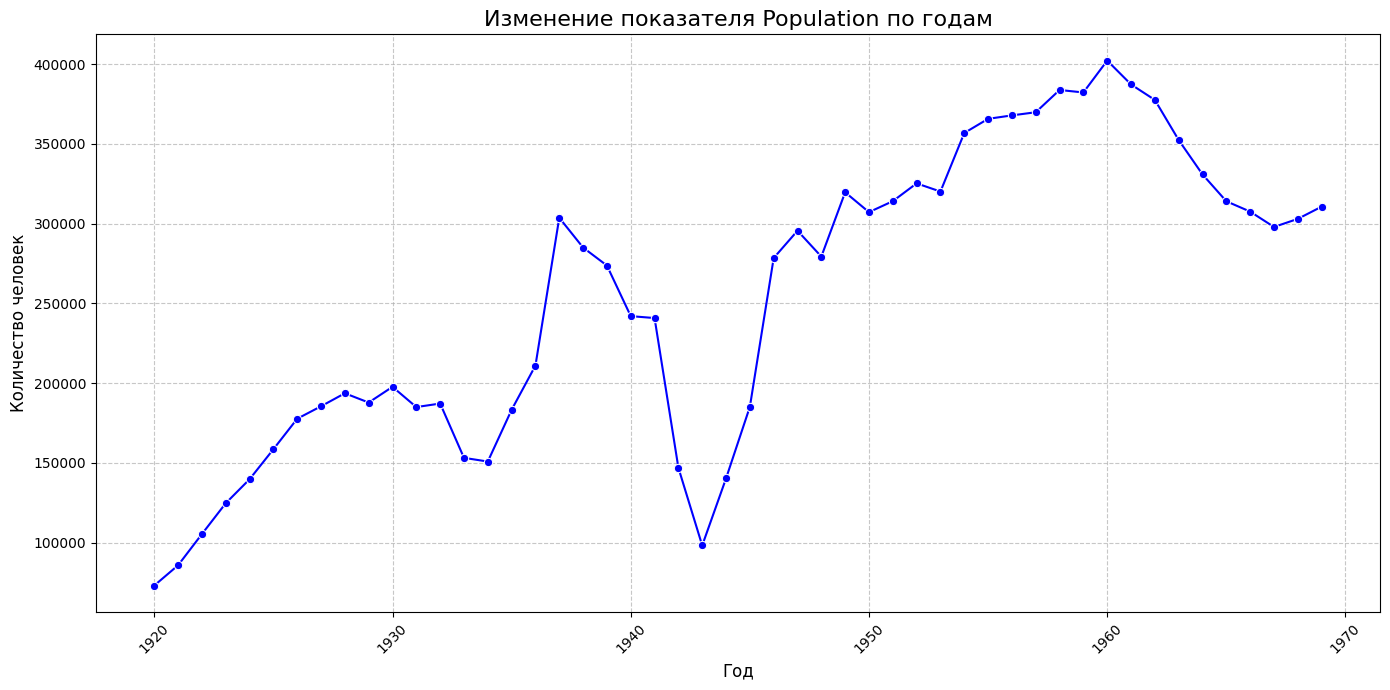

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Извлечение данных для 'population'
population_row = new_df.loc['population']

# Года - это колонки, исключая 'sex'
years_for_plot = [year for year in years]

# Извлечение численных значений популяции по годам
# При этом столбец 'sex' для строки 'population' будет NaN, его нужно исключить
population_values = population_row[years_for_plot].astype(float).values

# Преобразование годов в целочисленный тип для корректного отображения оси X
years_for_plot_int = [int(year) for year in years_for_plot]

plt.figure(figsize=(14, 7))
sns.lineplot(x=years_for_plot_int, y=population_values, marker='o', color='blue')
plt.title('Изменение показателя Population по годам', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()